In [1]:
import numpy as np
from matplotlib import pyplot as plt

#data = np.fromfile('data_gil_500.bin', dtype = np.float64).reshape(6,-1)
data = np.fromfile('data_gil_5000.bin', dtype = np.float64).reshape(6,-1)
#data = np.fromfile('data_gil_100000.bin', dtype = np.float64).reshape(6,-1)
omega=5000
X01 = data[0]/omega
X02 = data[1]/omega
X11 = data[2]/omega
X12 = data[3]/omega
V0 = data[4]
RT = data[5]

a=2
b=4.5
c=1
d=1

s_plus = (b*d**2+c*a**2)/(d*c*a)
u_plus = c*a**2/(c*a**2+b*d**2)
u_minus = 0

s_plus, u_plus

(4.25, 0.47058823529411764)

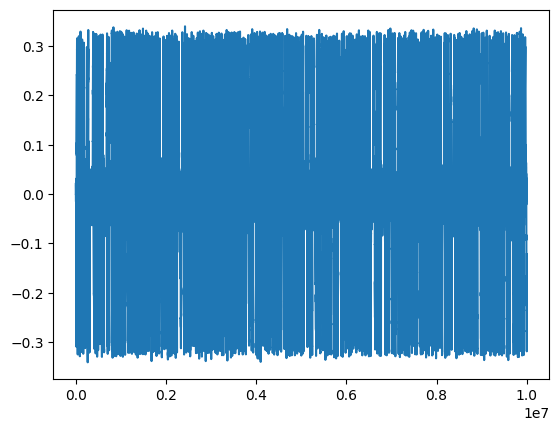

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
data = np.fromfile('data_gil_5000.bin', dtype = np.float64).reshape(6,-1)
omega=5000
X01 = data[0]/omega
X02 = data[1]/omega
X11 = data[2]/omega
X12 = data[3]/omega
V0 = data[4]
RT = data[5]

a=2
b=4.5
c=1
d=1

s_plus = (b*d**2+c*a**2)/(d*c*a)
u_plus = c*a**2/(c*a**2+b*d**2)
u_minus = 0

S0 = X01 + X02
S1 = X11 + X12
U0 = X01/S0
U1 = X11/S1

S_plus = S0 + S1
S_minus = S0 - S1
U_plus = (U0 + U1)/2
U_minus = (U0 - U1)/2


In [3]:
S0 = X01 + X02
S1 = X11 + X12
U0 = X01/S0
U1 = X11/S1

S_plus = S0 + S1
S_minus = S0 - S1
U_plus = (U0 + U1)/2
U_minus = (U0 - U1)/2

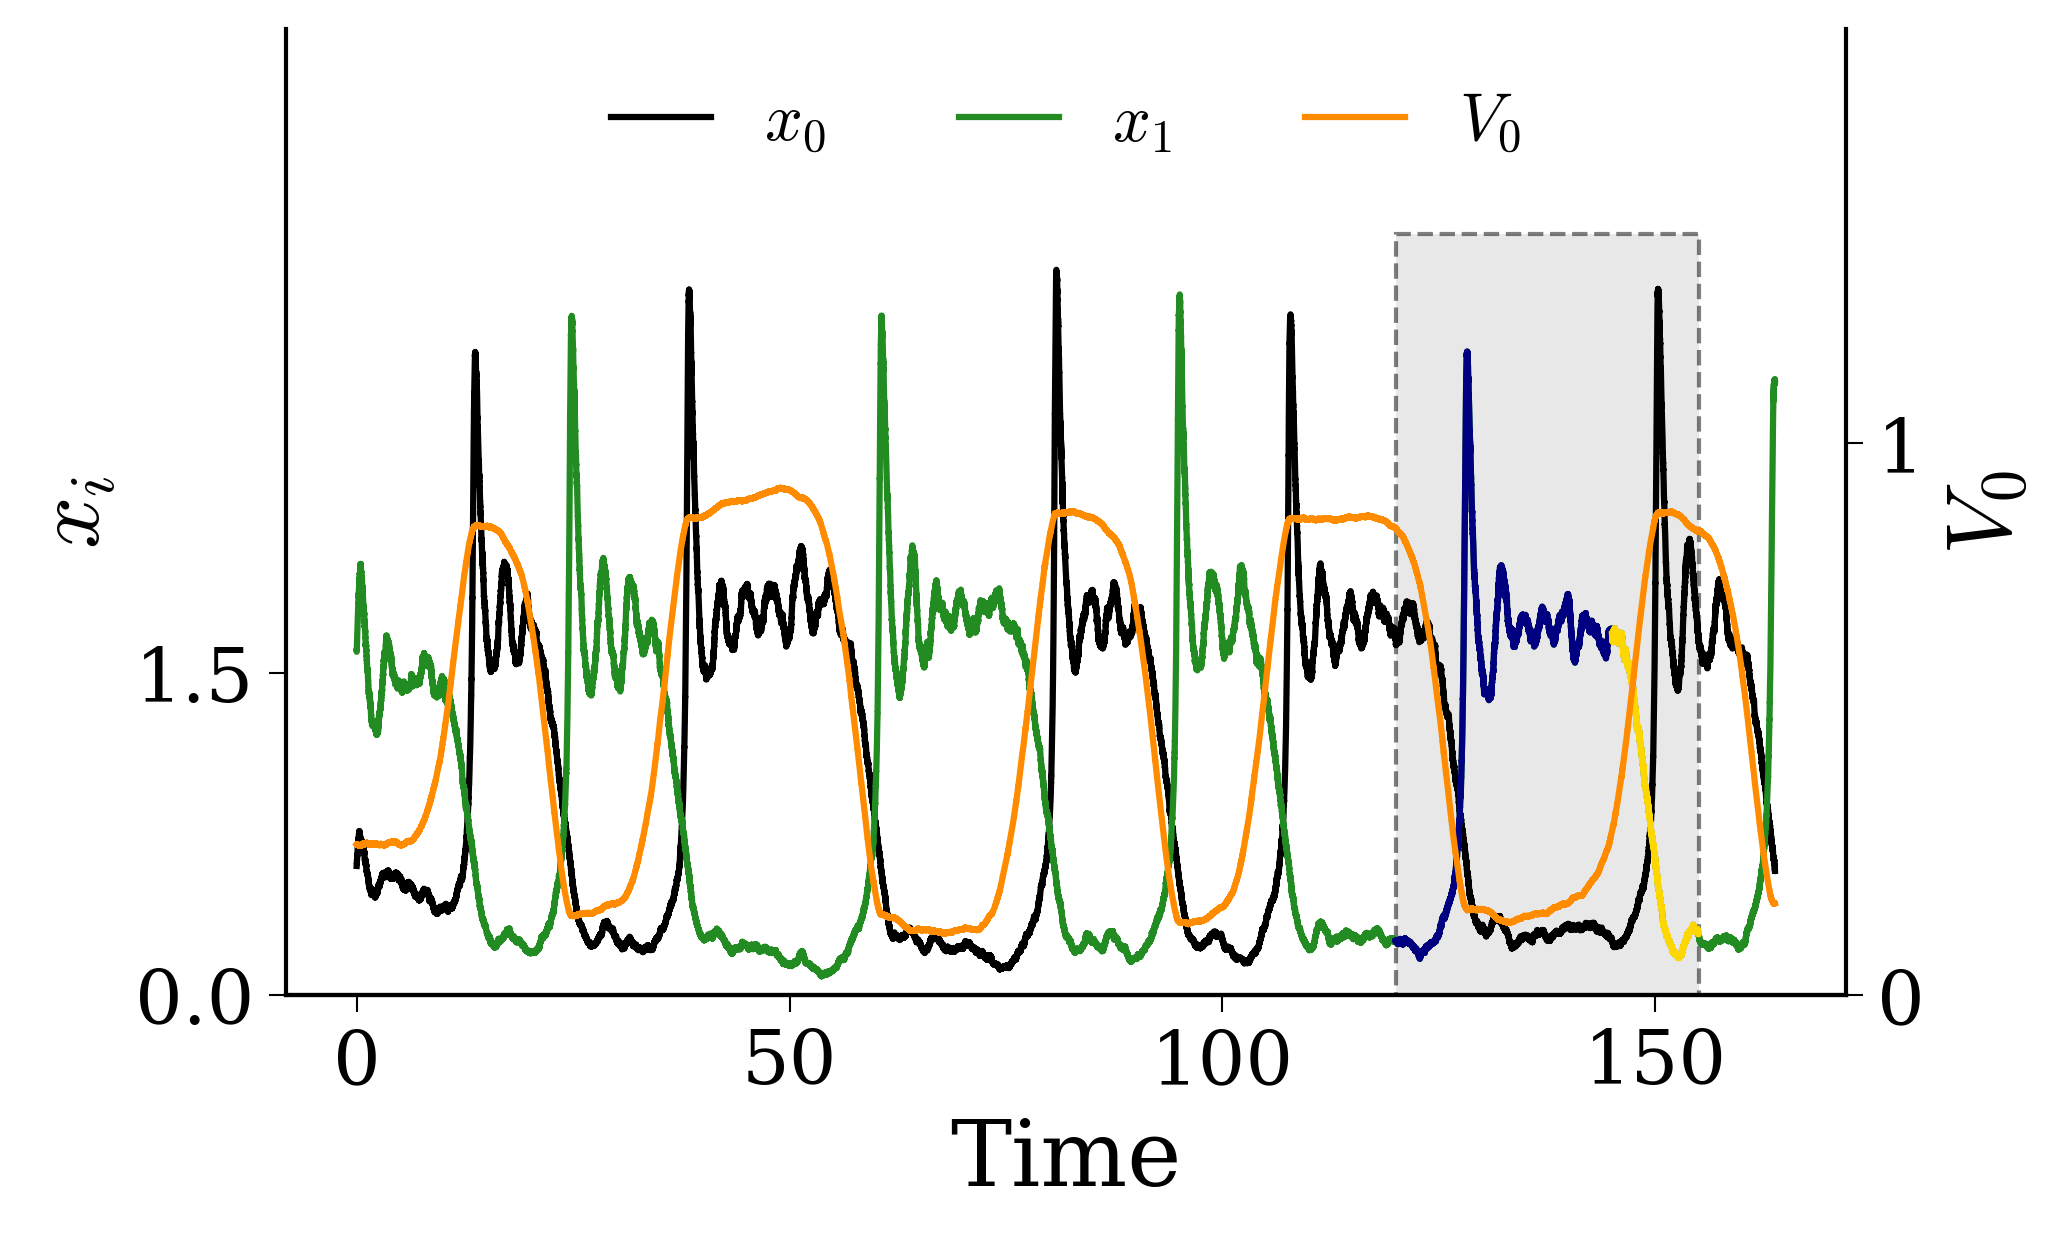

In [ ]:
from matplotlib import patches as mpatches
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')
final = 180000
fig, ax = plt.subplots(1, 1,figsize=(6.75, 4))
ax2 = ax.twinx()

plt1 = ax.plot(RT[:final], X01[:final], color='black', label=f'$x_0$')
plt2 = ax.plot(RT[:final], X11[:final], color='forestgreen', label=f'$x_1$')
plt3 = ax2.plot(RT[:final], V0[:final], color='darkorange', label=f'$V_0$')

lns = [plt1[0], plt2[0], plt3[0]]
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, ncol=3,loc='upper center',fontsize=16)

designed_line_start = np.searchsorted(RT, 120)
designed_line_end   = np.searchsorted(RT, 145)
ax.plot(RT[designed_line_start:designed_line_end],
        X11[designed_line_start:designed_line_end],
        color='navy', linewidth=1.5)

designed_line_start = np.searchsorted(RT, 145)
designed_line_end   = np.searchsorted(RT, 155)
ax.plot(RT[designed_line_start:designed_line_end],
        X11[designed_line_start:designed_line_end],
        color='gold', linewidth=1.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)   
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)   
ax2.spines['right'].set_visible(True)   

x_start = RT[np.searchsorted(RT, 120)]
x_end   = RT[np.searchsorted(RT, 155)]
y_min, y_max = ax.get_ylim()          

rect = mpatches.Rectangle(
    (x_start, y_min),                  
    x_end - x_start,                   
    y_max - y_min,                     
    linewidth=1,
    edgecolor='black',
    ls='--',
    facecolor='lightgray',
    alpha=0.5,
    zorder=0,                          
)
ax.add_patch(rect)

ax.set_xlabel('Time')
ax.set_ylabel('$x_i$')
ax.set_ylim(0, 4.5)
ax2.set_ylabel('$V_0$')
ax.set_yticks(np.array([0,1.5]))
ax2.set_ylim(0, 1.75)
ax2.set_yticks(np.arange(0, 2, 1))

ax.tick_params(top=False)
ax2.tick_params(top=False)

ax.tick_params(right=False)

ax2.tick_params(left=False)

fig.savefig('Fig2/concentrations.png')
plt.show()

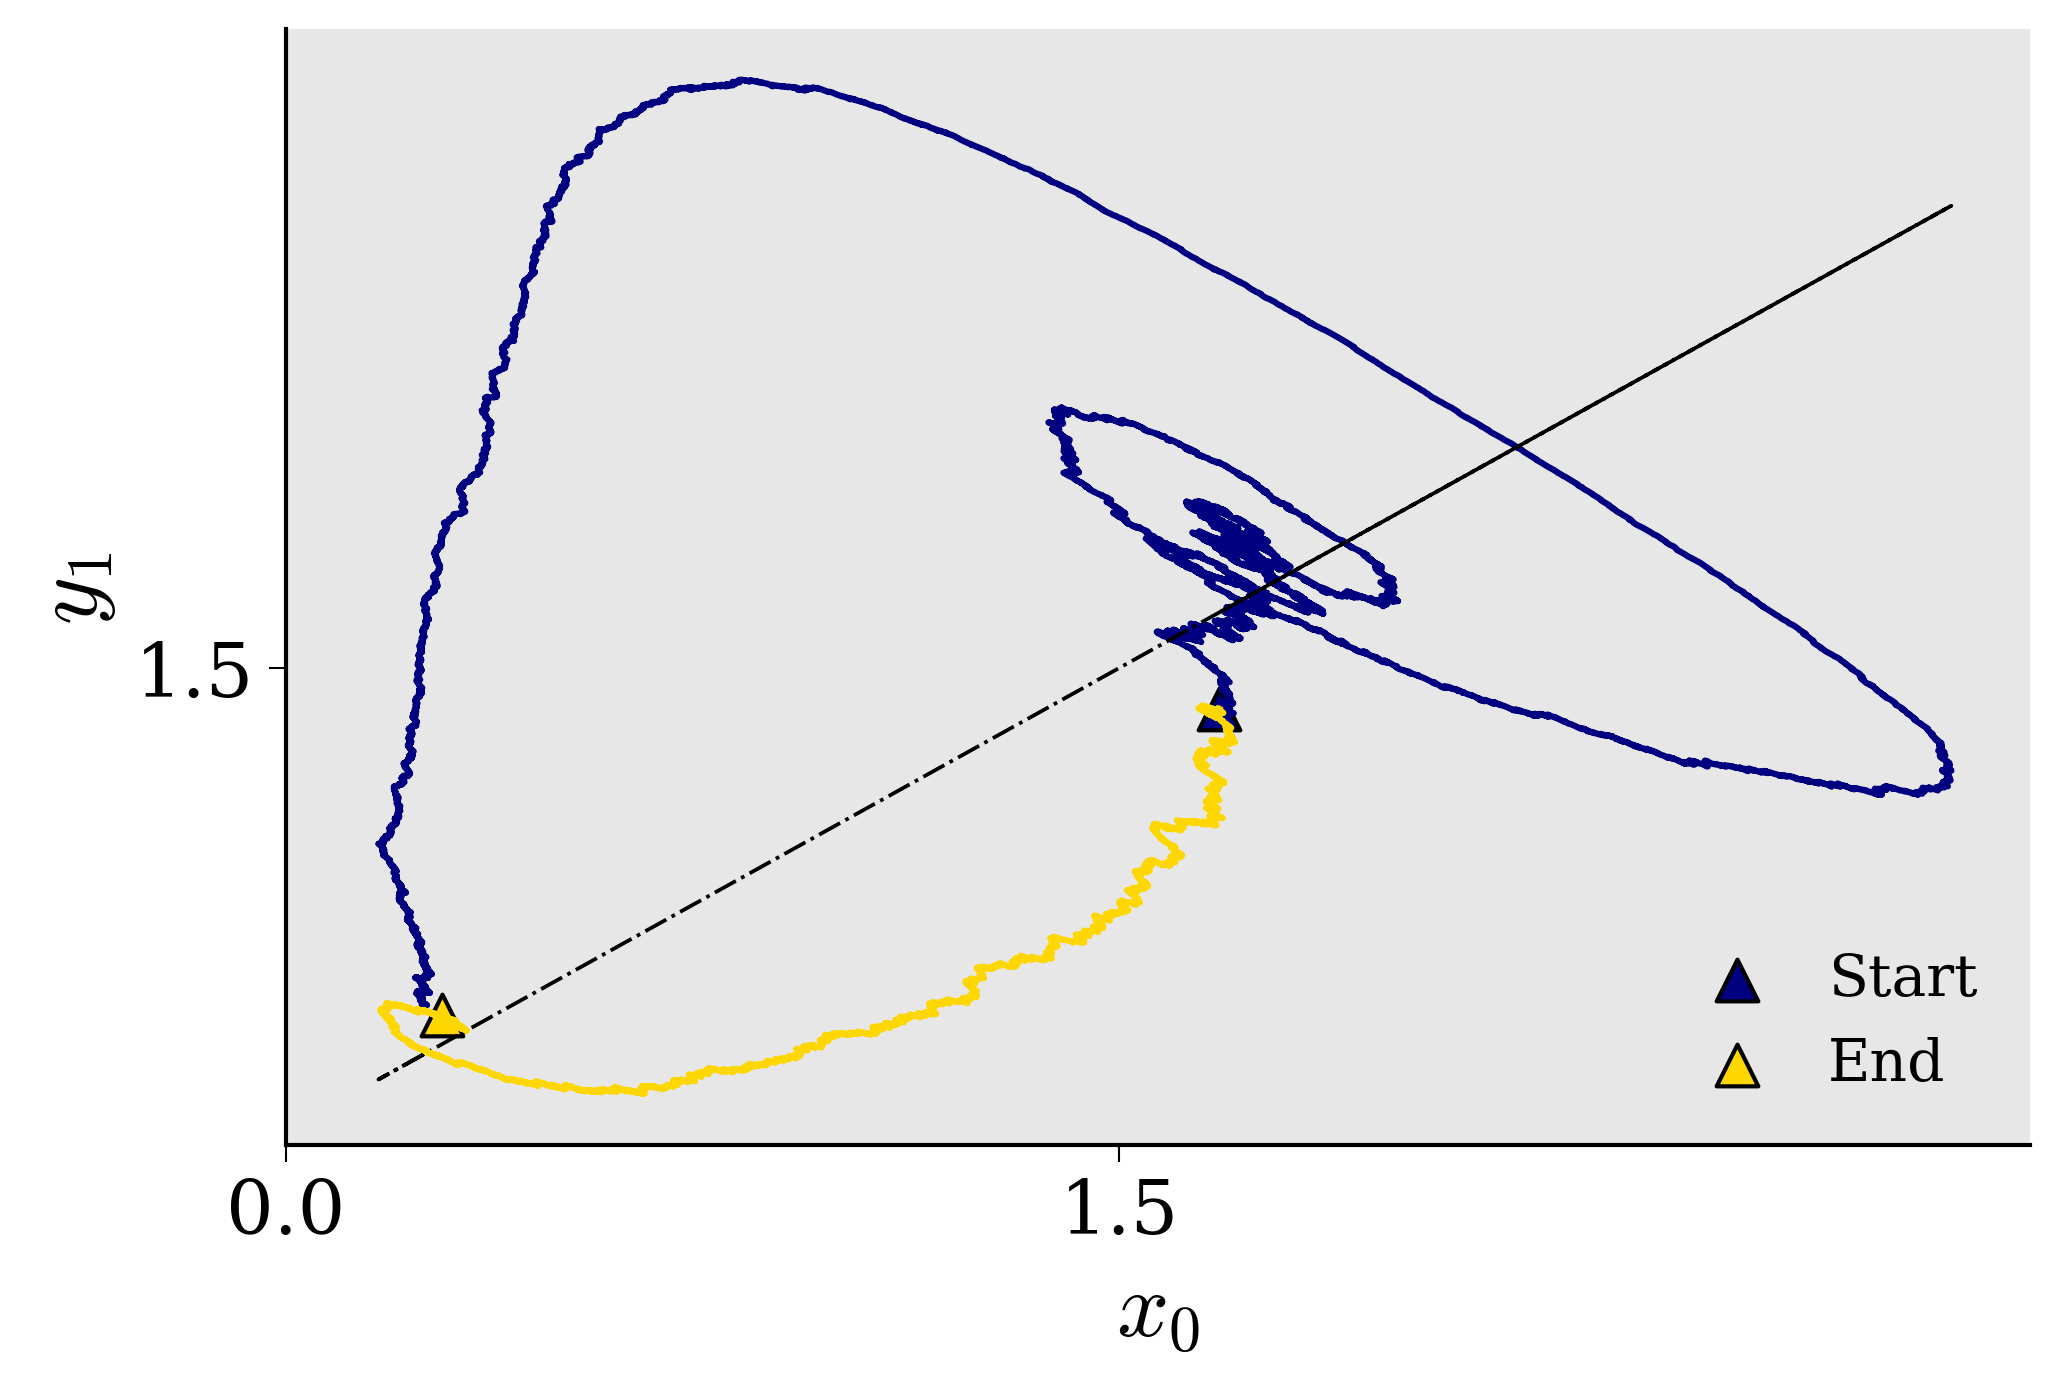

In [ ]:
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')
fig, ax = plt.subplots(1, 1,)

designed_line_start = np.searchsorted(RT, 120)
designed_line_end   = np.searchsorted(RT, 145)
ax.plot(X11[designed_line_start:designed_line_end], X12[designed_line_start:designed_line_end], color='navy')
ax.plot(X11[designed_line_start:designed_line_end],X11[designed_line_start:designed_line_end],ls='-.',color='black',lw=0.9)

designed_line_start = np.searchsorted(RT, 145)
designed_line_end   = np.searchsorted(RT, 155)
ax.plot(X11[designed_line_start:designed_line_end], X12[designed_line_start:designed_line_end], color='gold')

ax.scatter(X11[designed_line_start], X12[designed_line_start], color='navy', s=100, marker = '^', label = 'Start', edgecolors='black')
ax.scatter(X11[designed_line_end], X12[designed_line_end], color='gold', s=100, marker = '^', label = 'End', edgecolors='black')
#ax.plot(X11[designed_line_start:designed_line_end],X11[designed_line_start:designed_line_end],ls='-.',color='black',lw=0.9)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$y_1$')
ax.set_yticks(np.array([1.5]))
ax.set_xticks(np.array([0,1.5]))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)  
ax.tick_params(right=False)
ax.tick_params(top=False)

ax.set_facecolor((0.1, 0.1, 0.1, 0.1))

ax.legend()
fig.savefig('Fig2/trajectory.png')
plt.show()

In [16]:
V0

array([0.27272727, 0.27280507, 0.27277395, ..., 0.8308186 , 0.83090089,
       0.83095739], shape=(10000000,))

/var/folders/tx/tcb2jb8j5wv__2wyr30by0gc0000gn/T/ipykernel_9893/1346357856.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


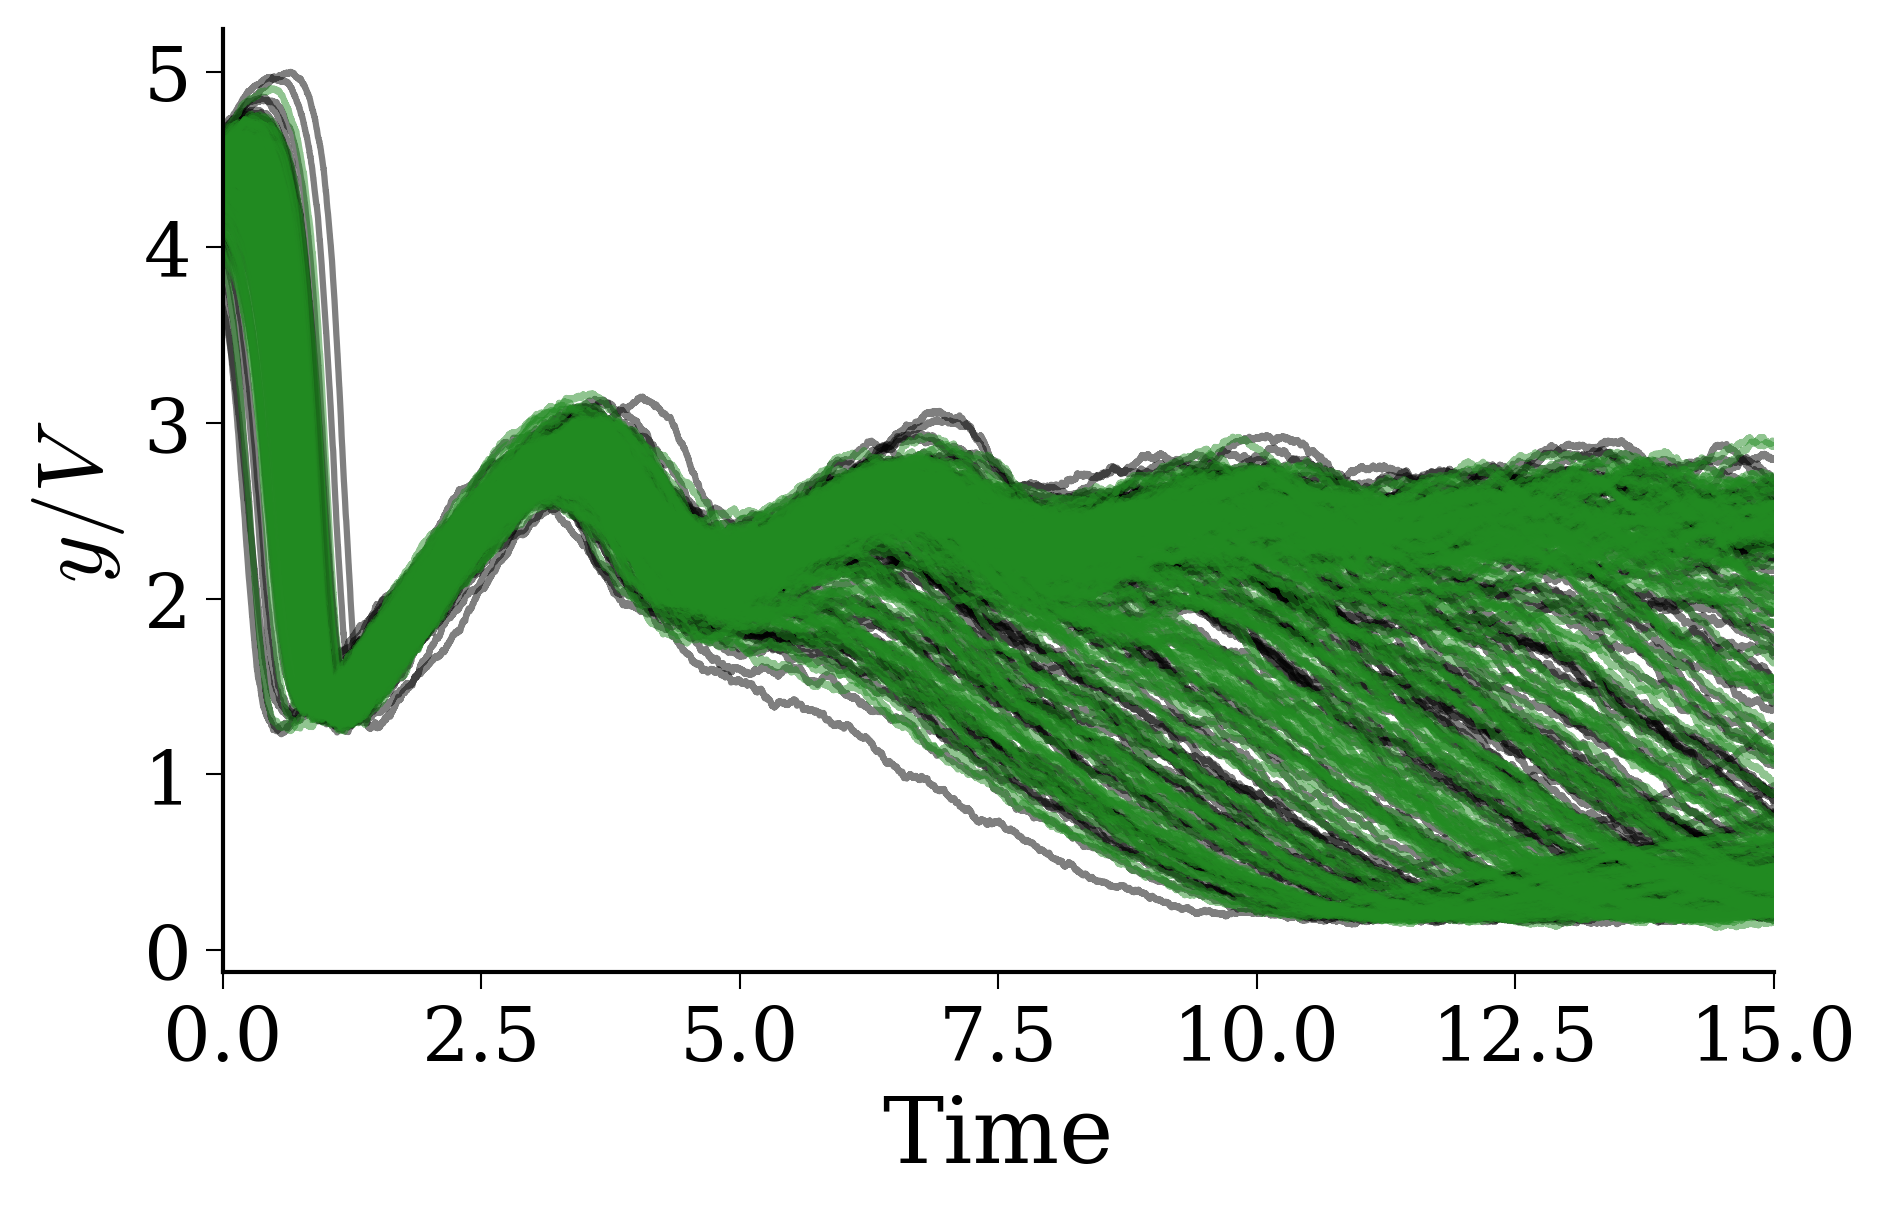

In [18]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')

data = np.fromfile('data_gil_5000.bin', dtype=np.float64).reshape(6, -1)

omega = 5000
X01 = data[0] / omega
X02 = data[1] / omega
X11 = data[2] / omega
X12 = data[3] / omega
V0  = data[4]
RT  = data[5]

dt_mean = RT[-1] / len(RT)
delta   = int(30 / dt_mean)

fig, ax = plt.subplots(1, 1)

# Finestre nere: V0 alto, X02/V0 parte da > 3.5
i = 0
while i < len(RT) - delta:
    if V0[i] > 0.8:
        if (X02[i] / V0[i]) > 3.5:
            t_window = RT[i:i + delta] - RT[i]
            y_window = X02[i:i + delta] / V0[i]
            ax.plot(t_window, y_window, color='black', alpha=0.5)
        i += delta
    else:
        i += 1

# Finestre verdi: (1-V0) alto, X12/(1-V0) parte da > 3.5
i = 0
while i < len(RT) - delta:
    if (1 - V0[i]) > 0.8:
        if (X12[i] / (1 - V0[i])) > 3.5:
            t_window = RT[i:i + delta] - RT[i]
            y_window = X12[i:i + delta] / (1 - V0[i])
            ax.plot(t_window, y_window, color='forestgreen', alpha=0.5)
        i += delta
    else:
        i += 1

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_xlabel('Time')
ax.set_ylabel('$y/V$')
ax.set_xlim(0, 15)

plt.tight_layout()
plt.show()

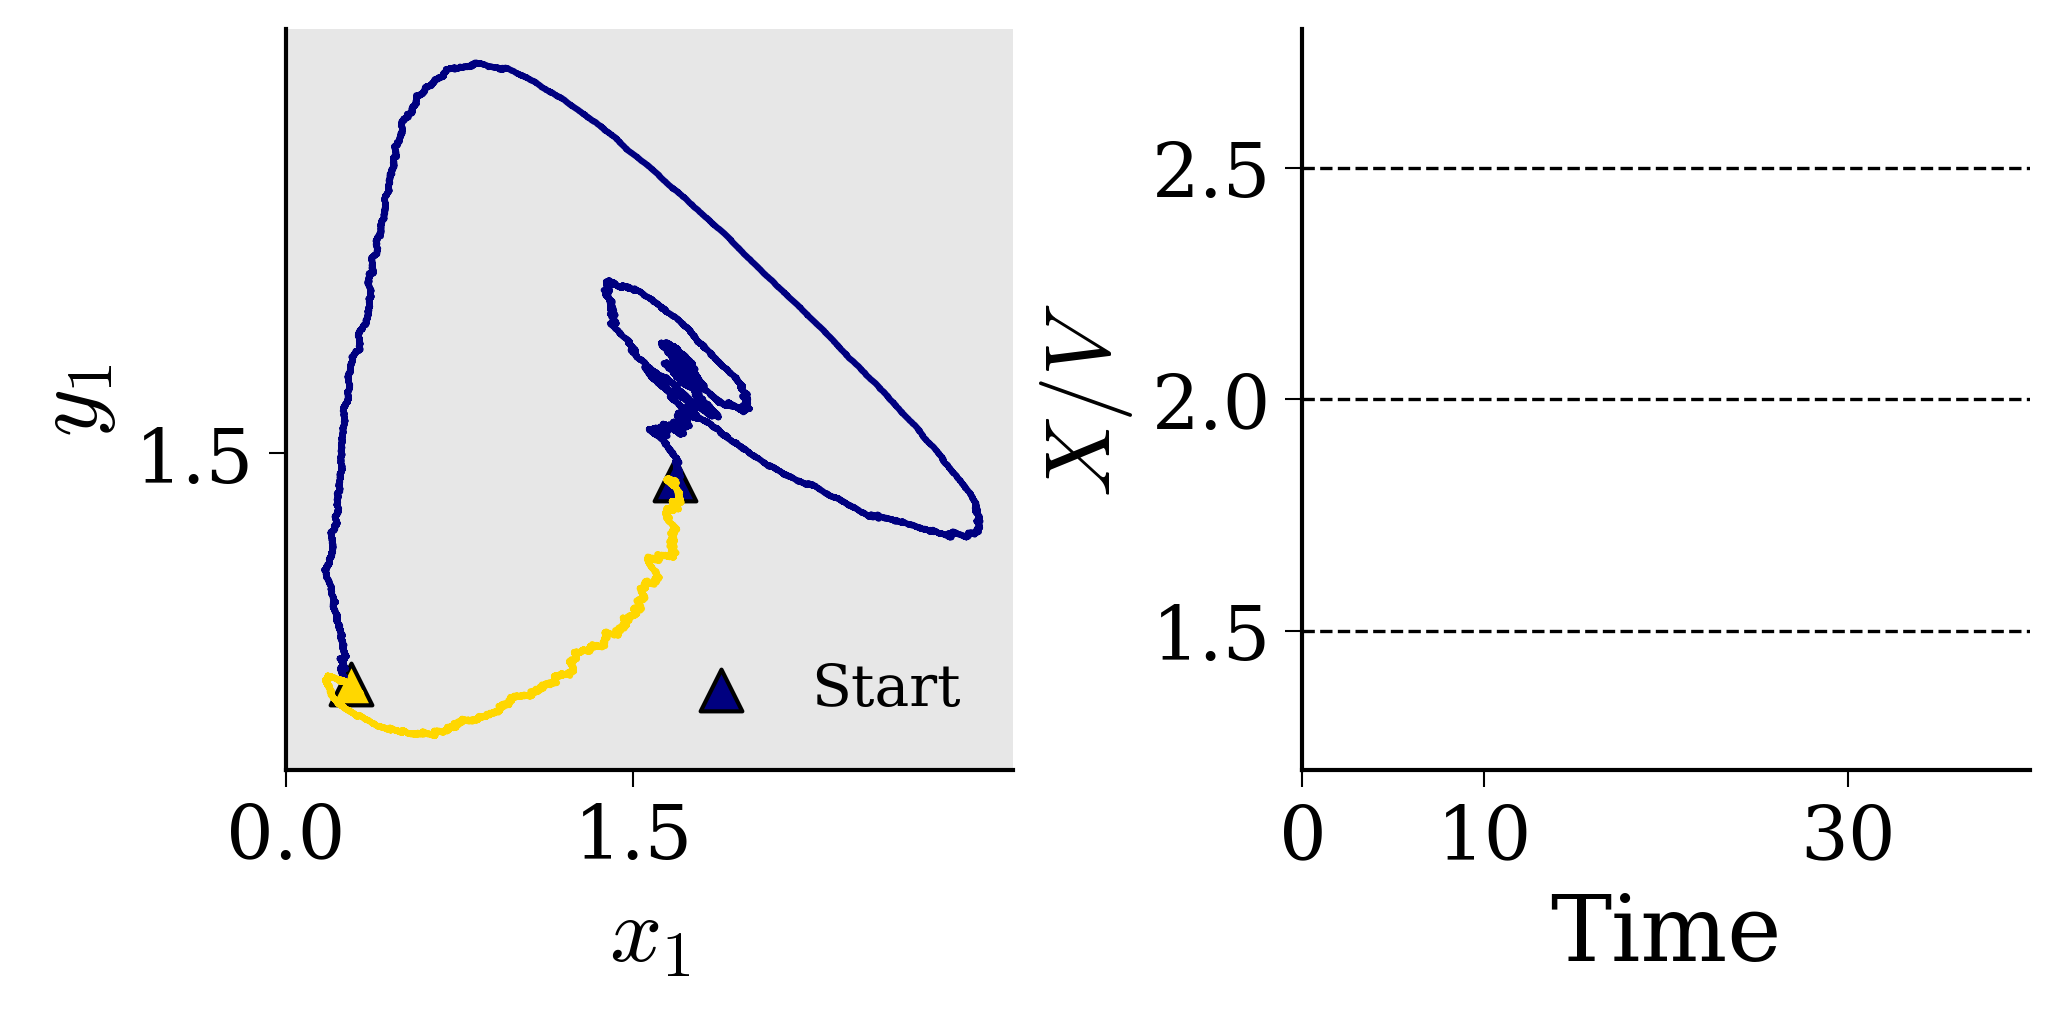

In [23]:
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')

fig, ax = plt.subplots(1, 2, figsize=(6.75, 3.25))

designed_line_start = np.searchsorted(RT, 120)
designed_line_end   = np.searchsorted(RT, 145)
ax[0].plot(X11[designed_line_start:designed_line_end], X12[designed_line_start:designed_line_end], color='navy')


designed_line_start = np.searchsorted(RT, 145)
designed_line_end   = np.searchsorted(RT, 155)
ax[0].plot(X11[designed_line_start:designed_line_end], X12[designed_line_start:designed_line_end], color='gold')

ax[0].scatter(X11[designed_line_start], X12[designed_line_start], color='navy', s=100, marker = '^', label = 'Start', edgecolors='black')
ax[0].scatter(X11[designed_line_end], X12[designed_line_end], color='gold', s=100, marker = '^', edgecolors='black')
#ax[0].plot(X11[designed_line_start:designed_line_end],X11[designed_line_start:designed_line_end],ls='-.',color='black',lw=0.9)
#ax[0].plot(X11[np.searchsorted(RT, 120):np.searchsorted(RT, 155)],X11[np.searchsorted(RT, 120):np.searchsorted(RT, 155)],ls='-.',color='black',lw=1.8)

ax[0].set_xlabel('$x_1$')
ax[0].set_ylabel('$y_1$')
ax[0].set_yticks(np.array([1.5]))
ax[0].set_xticks(np.array([0,1.5]))

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)  
ax[0].tick_params(right=False)
ax[0].tick_params(top=False)

ax[0].set_facecolor((0.1, 0.1, 0.1, 0.1))

ax[0].legend(loc='lower right')

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)  
 
ax[1].set_xlabel('Time')
ax[1].set_ylabel('$X/V$')
ax[1].axhline(y=1.5, color='black', linestyle='--', linewidth=0.8)
ax[1].axhline(y=2, color='black', linestyle='--', linewidth=0.8)
ax[1].axhline(y=2.5, color='black', linestyle='--', linewidth=0.8)
ax[1].set_ylim(1.2, 2.8)
ax[1].set_xlim(0, 40)
ax[1].set_yticks([1.5,2,2.5])
ax[1].set_xticks([0,10,30])

fig.savefig('Fig2/trajectory.png')
plt.show()

In [20]:
X01

array([0.5998, 0.6012, 0.6018, ..., 2.4032, 2.4094, 2.4112],
      shape=(10000000,))

<>:156: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:163: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:168: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:156: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:163: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:168: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/tx/tcb2jb8j5wv__2wyr30by0gc0000gn/T/ipykernel_20532/23501

Periods = 687
Periods = 3113
Periods = 1413
Periods = 868
Periods = 469
Periods = 294
Periods = 209


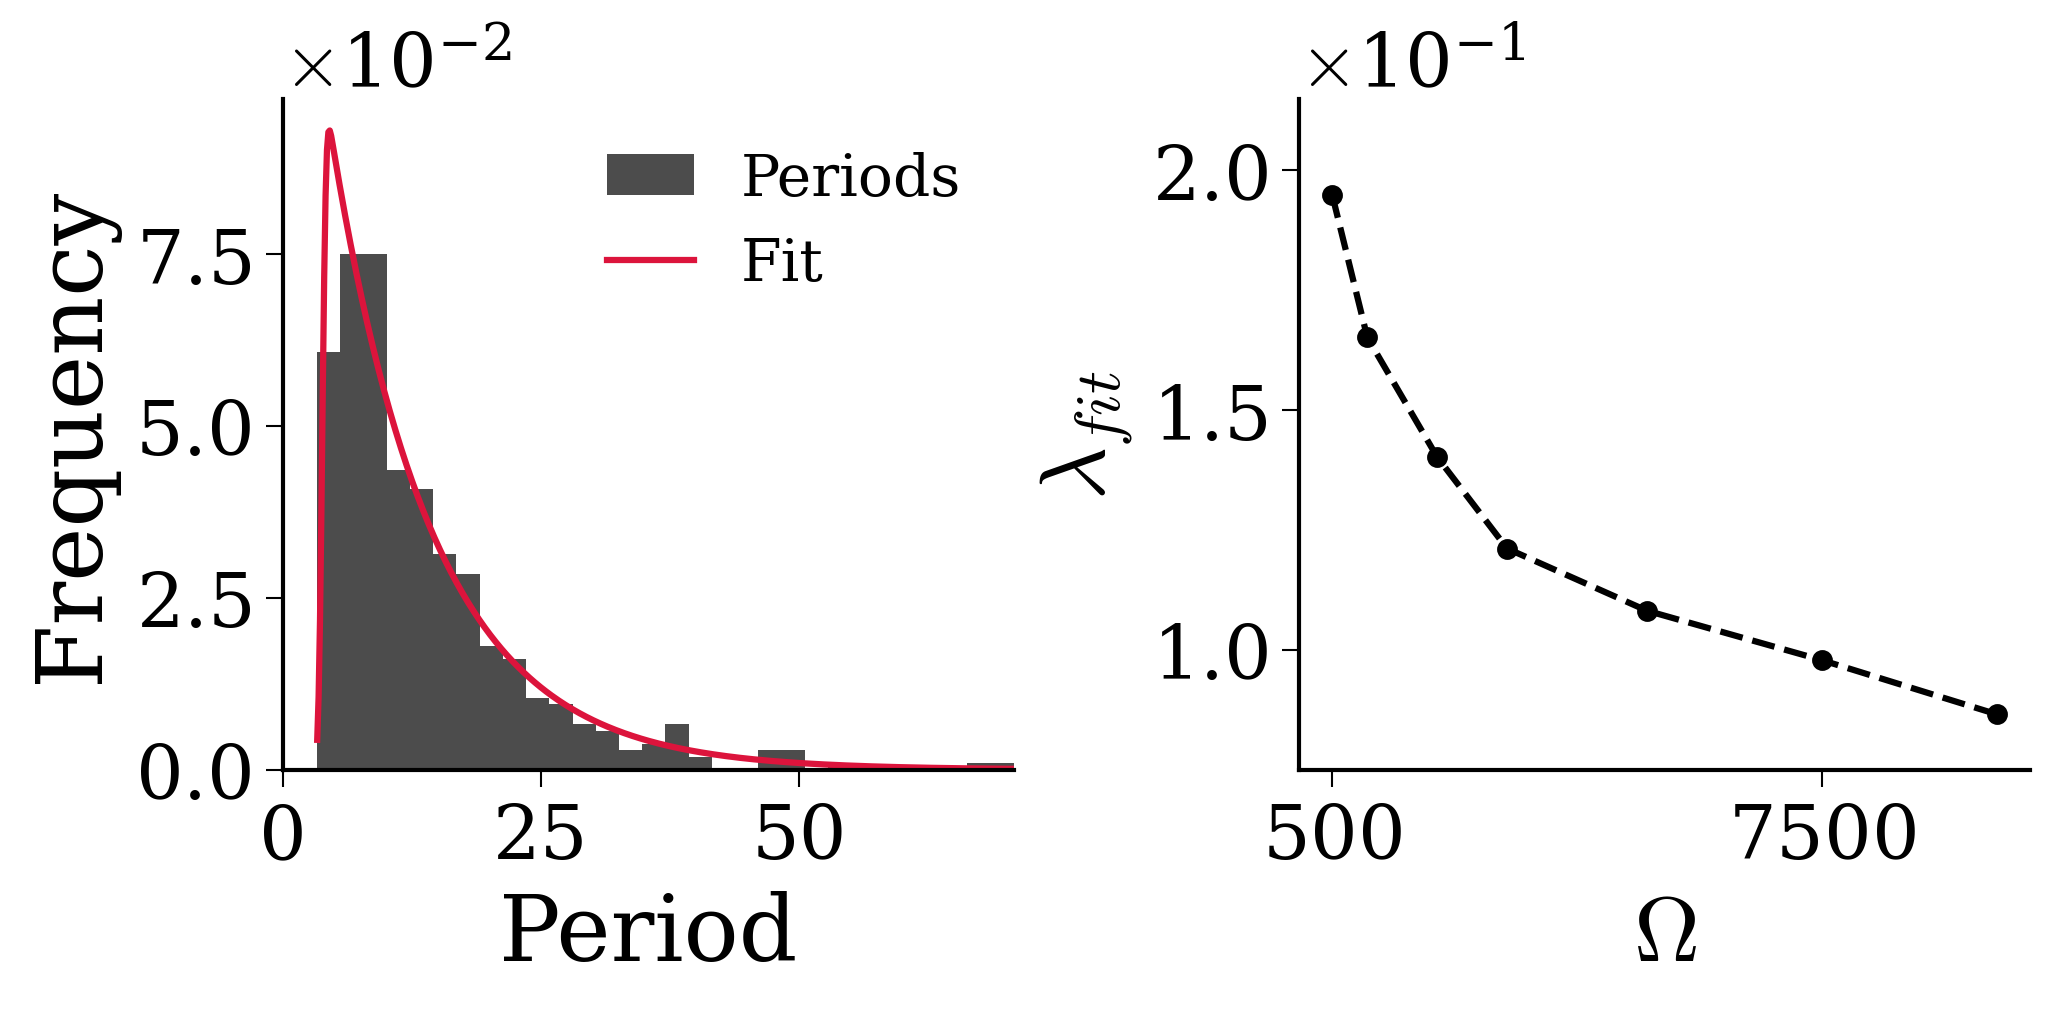

In [33]:
from scipy.signal import find_peaks
from scipy.stats import exponnorm
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

def compute_periods_vol(t, V,with_threshold = True):
    """
    Compute the periods of oscillation based on threshold crossings.
    """
    if with_threshold:
        V_smooth = savgol_filter(V, window_length=101, polyorder=3)
        dV = np.gradient(V_smooth, t)

        #
        thr =  0.09
        #thr = 0.45
        plateau = np.abs(dV) < thr

        change = np.diff(plateau.astype(int))

        starts = np.where(change == 1)[0] + 1
        ends   = np.where(change == -1)[0] + 1

        # casi limite
        if plateau[0]:
            starts = np.insert(starts, 0, 0)
        if plateau[-1]:
            ends = np.append(ends, len(plateau))

        periods = t[ends-1] - t[starts]
        periods = periods[periods > 3]
        periods = periods[periods < 80]

        return periods

    else:
        crossings = np.where(
            ((V[:-1] < 0.7) & (V[1:] >= 0.7)) |
            ((V[:-1] >= 0.7) & (V[1:] < 0.7))
        )[0] or np.where(
            ((V[:-1] < 0.3) & (V[1:] >= 0.3)) |
            ((V[:-1] >= 0.3) & (V[1:] < 0.3))
        )[0]

        t_cross = t[crossings]
        periods = np.diff(t_cross)
        periods = periods[periods > 4]
        
        return periods

def load_Gillespie_data(filename: str, omega: float) -> np.ndarray:
    """
    Load Gillespie simulation data from a binary file.
    The data is expected to be in the shape (6, N), where N is the number of time points.
    """
    data = np.fromfile(filename, dtype=np.float64).reshape(6, -1)
    V0 = data[4]
    RT = data[5]


    #traj = np.array([X01, X02, X11, X12])
    #traj_reduced = np.array([S_plus, S_minus, U_plus, U_minus])

    return RT,  V0

plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')
plt.rcParams.update({'xtick.top': False, 'ytick.right': False})
fig, ax = plt.subplots(1, 2, figsize=(6.75, 3.25))

'''threshold = 0.6
min_period = RT[5] - RT[0]

crossings = np.where(
    ((V0[:-1] < threshold) & (V0[1:] >= threshold)) |
    ((V0[:-1] >= threshold) & (V0[1:] < threshold))
)[0]

t_cross  = RT[crossings]
periods  = np.diff(t_cross)
periods  = periods[periods > min_period]

T = 0
periods = np.array([])
for i in range(len(V0) - 1):
    if np.abs(V0[i + 1] - V0[i]) / (RT[i + 1] - RT[i]) < 5e-2:
        T += RT[i + 1] - RT[i]
    else:
        if T > 0:
            periods = np.append(periods, T)
            T = 0

if T > 0:
    periods = np.append(periods, T)

periods = periods[periods > (RT[5] - RT[0])]'''

dRT = np.diff(RT)
dV = np.diff(V0)

# maschera booleana: True dove la variazione è sotto soglia
mask = np.abs(dV) / dRT < 0.45

# individua inizio/fine dei blocchi consecutivi di True
padded = np.concatenate(([False], mask, [False]))
edges = np.diff(padded.astype(int))
starts = np.where(edges == 1)[0]
ends   = np.where(edges == -1)[0]

# somma i dRT dentro ciascun blocco -> durata di ogni periodo
periods = np.array([dRT[s:e].sum() for s, e in zip(starts, ends)])
periods = periods[periods > 4]

periods = compute_periods_vol(RT, V0, with_threshold=True)

K, mu, sigma = exponnorm.fit(periods)

x_fit = np.linspace(periods.min(), periods.max(), 500)
y_fit = exponnorm.pdf(x_fit, K, mu, sigma)

ax[0].hist(periods, bins=30, density=True, color='black', alpha=0.7, label='Periods')
ax[0].plot(x_fit, y_fit, color='crimson', linewidth=1.5,
        label=f'Fit')

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].tick_params(top=False, right=False)
ax[0].set_ylabel('Frequency')
ax[0].set_xlabel('Period')
ax[0].ticklabel_format(style='sci',axis='y',scilimits=(0, 0),useMathText=True)
#ax[0].set_yticks([0])
ax[0].set_xlim(0, periods.max())
ax[0].legend()


Volumes = [500, 1000,2000, 3000, 5000,7500,10000,]


arr_lambda = []

file_path = '../Stochastic-Volume-Oscillations/FIG1/'
data_file =np.array(['data_gil_500.bin','data_gil_1000.bin','data_gil_2000.bin','data_gil_3000.bin','data_gil_5000.bin','data_gil_7500.bin','data_gil_10000.bin',])
for i, filename in enumerate(data_file):
    t_G, V0_G = load_Gillespie_data(filename, Volumes[i])
    periods_G = compute_periods_vol(t_G, V0_G, with_threshold=True )    
    #params = fit_exgaussian(periods_G)
    counts, bin_edges = np.histogram(periods_G, bins=20)
    print('Periods =',np.sum(counts))
    bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])
    idx_max = np.argmax(counts)
    x_peak = bin_centers[idx_max]

    periods_MLE = periods_G[periods_G > x_peak]
    lam_MLE = 1/np.mean(periods_MLE - x_peak)
    arr_lambda.append(lam_MLE)

ax[1].plot(Volumes, arr_lambda, marker='o',ls='--', color='black', label='$\lambda_{fit}$')

ax[1].set_xticks([500,7500])
#ax[1].set_yticks([0.1,0.15,0.2])
ax[1].ticklabel_format(style='sci',axis='y',scilimits=(0, 0),useMathText=True)
#ax[1].set_xticklabels([r'$10^2$', r'$10^4$'],fontfamily='serif')
ax[1].ticklabel_format(style='sci',axis='x',useMathText=True)
ax[1].set_xlabel('$\Omega$')
#
ax[1].set_ylim(0.075, 0.215)
#ax[1].set_xlim(0,12000)
#ax[1].yaxis.set_label_coords(-0.08, 0.5)
ax[1].set_ylabel('$\lambda_{fit}$')
plt.savefig('Fig2/period_distribution.png')
plt.show()
